# Tarea 2

# Integrantes:
- Sofía Salinas Rico - ssalinas@unal.edu.co
- Camilo Chitivo Cerinza - cchitivo@unal.edu.co

Considere un tablero de ajedrez estándar de $8×8$
.

Las columnas del tablero se identifican mediante las letras 𝑎,𝑏,𝑐,𝑑,𝑒,𝑓,𝑔,ℎ

y las filas mediante los números $1,2,…,8.$

Por tanto, cada casilla se identifica mediante una letra y un número. 
El tablero queda identificado de la siguiente manera:

$$
\begin{array}{c|c|c|c|c|c|c|c|c}
\hline
8 & a8 & b8 & c8 & d8 & e8 & f8 & g8 & h8 \\ \hline
7 & a7 & b7 & c7 & d7 & e7 & f7 & g7 & h7 \\ \hline
6 & a6 & b6 & c6 & d6 & e6 & f6 & g6 & h6 \\ \hline
5 & a5 & b5 & c5 & d5 & e5 & f5 & g5 & h5 \\ \hline
4 & a4 & b4 & c4 & d4 & e4 & f4 & g4 & h4 \\ \hline
3 & a3 & b3 & c3 & d3 & e3 & f3 & g3 & h3 \\ \hline
2 & a2 & b2 & c2 & d2 & e2 & f2 & g2 & h2 \\ \hline
1 & a1 & b1 & c1 & d1 & e1 & f1 & g1 & h1 \\ \hline
  & a  & b  & c  & d  & e  & f  & g  & h  \\
\end{array}
$$


Considere un  caballo que se desplaza aleatoriamente sobre el tablero. Suponga que no hay otras piezas. El caballo realiza los movimientos usuales del ajedrez, se mueve formando una letra "L" mayúscula: avanza dos casillas en línea recta (en dirección vertical u horizontal) y luego da un giro de una casilla hacia un lado en ángulo recto. En cada movimiento, el caballo elige uniformemente al azar una de las casillas a las que puede desplazarse legalmente desde su posición actual.

Sea $X_n=$
posición del caballo en el 𝑛
-ésimo movimiento,  $𝑛=0,1,2,...$

De esta manera, $X=(X_n)_{n \geq 0}$
 es una Cadena de Markov.

# Ejercicios

## 1. Construcción de la cadena de Markov.

a) Describa el espacio de estados $S$ del proceso $X=(X_n)_{n \geq 0}$. ¿Cuántos estados tiene?

b) Para un estado $x\in S$, defina

$N(x) = \{y \in S : \text{el caballo puede pasar de } x \text{ a } y \text{ en un solo movimiento}\}$

$$|N(x)| = \operatorname{cardinal}(N(x))$$

Determine $N(x)$ y $|N(x)|$ para cada $x \in S$. Presente los resultados en una tabla que contenga $x$, $N(x)$, $|N(x)|$.

**c)** Teniendo en cuenta que el caballo elige moverse uniformemente entre todos los movimientos legales disponibles desde $x$, calcule las probabilidades de transición:

$$P_{xy} = P(X_{n+1} = y \mid X_n = x) = \begin{cases} \frac{1}{|N(x)|}, & y \in N(x) \\ 0, & y \notin N(x) \end{cases}$$

Ejemplo:

$$P_{a1,y} = \begin{cases} \frac{1}{2}, & y = b3, c2 \\ 0, & \text{caso contrario} \end{cases}$$

**d)** Presente las probabilidades de transición $P_{h8,y}$, $P_{g1,y}$, $P_{b7,y}$, $P_{f7,y}$, $P_{e5,y}$.

**e)** Fije un orden para las 64 casillas del tablero. Por ejemplo, puede utilizar:

$$a1, a2, \dots, a8, b1, b2, \dots, b8, \dots, h1, \dots, h8$$

Construya la matriz de transición $P = (P_{xy})_{x,y \in S}$.

La matriz puede ser construida utilizando un programa, incluya en el informe el código utilizado (o el enlace al código usado). No es necesario escribir todas sus entradas. Incluya en el informe, al menos, las filas de la matriz correspondientes a las casillas $g1$ y $h6$.

**f)** ¿La matriz $P$ es simétrica? Justifique su respuesta.


In [103]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [87]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


a) Tradicionalmente los caballos inician en $b1, g1, b8$ y $g8$, supongamos que $X_0 = b1$, luego el espacio de estados $S$ se define como parejas $x,y$ tales que  $x\in \{ a,b,c,d,e,f,h \}$ y  $ 1< y \leq 8$

para saber cuantos estados tenemos hagamos una función que recorre el tablero.

In [88]:
def posibles_vecinos(x,y):
    return [(x+1,y+2),(x+1,y-2),(x-1,y+2),(x-1,y-2),(x+2,y+1),(x+2,y-1),(x-2,y+1), (x-2,y-1) ]
def vecinos_validos(x,y):
    return [(i,j) for (i,j) in posibles_vecinos(x,y) if i>=1 and i<=8 and j>=1 and j<=8]


vamos a utilizar dos aproach para este proyecto, uno iterativo por cada una de las casillas y otro recursivo

In [89]:
def todos_los_vecinos_validos_iterativo():
    return { (i,j):vecinos_validos(i,j) for i in range(1,9) for j in range(1,9) }

In [90]:
todos_los_vecinos_iterativo = todos_los_vecinos_validos_iterativo()
print(todos_los_vecinos_iterativo)

{(1, 1): [(2, 3), (3, 2)], (1, 2): [(2, 4), (3, 3), (3, 1)], (1, 3): [(2, 5), (2, 1), (3, 4), (3, 2)], (1, 4): [(2, 6), (2, 2), (3, 5), (3, 3)], (1, 5): [(2, 7), (2, 3), (3, 6), (3, 4)], (1, 6): [(2, 8), (2, 4), (3, 7), (3, 5)], (1, 7): [(2, 5), (3, 8), (3, 6)], (1, 8): [(2, 6), (3, 7)], (2, 1): [(3, 3), (1, 3), (4, 2)], (2, 2): [(3, 4), (1, 4), (4, 3), (4, 1)], (2, 3): [(3, 5), (3, 1), (1, 5), (1, 1), (4, 4), (4, 2)], (2, 4): [(3, 6), (3, 2), (1, 6), (1, 2), (4, 5), (4, 3)], (2, 5): [(3, 7), (3, 3), (1, 7), (1, 3), (4, 6), (4, 4)], (2, 6): [(3, 8), (3, 4), (1, 8), (1, 4), (4, 7), (4, 5)], (2, 7): [(3, 5), (1, 5), (4, 8), (4, 6)], (2, 8): [(3, 6), (1, 6), (4, 7)], (3, 1): [(4, 3), (2, 3), (5, 2), (1, 2)], (3, 2): [(4, 4), (2, 4), (5, 3), (5, 1), (1, 3), (1, 1)], (3, 3): [(4, 5), (4, 1), (2, 5), (2, 1), (5, 4), (5, 2), (1, 4), (1, 2)], (3, 4): [(4, 6), (4, 2), (2, 6), (2, 2), (5, 5), (5, 3), (1, 5), (1, 3)], (3, 5): [(4, 7), (4, 3), (2, 7), (2, 3), (5, 6), (5, 4), (1, 6), (1, 4)], (3, 6

In [91]:
inicial = (2,1)
todos_los_vecinos_recursivos = {}
def todos_los_vecinos_validos_recursivo(x,y):
    nuevos_vecinos = vecinos_validos(x,y)
    todos_los_vecinos_recursivos[(x,y)] = nuevos_vecinos
    for vecino in nuevos_vecinos:
        if vecino not in todos_los_vecinos_recursivos:
            todos_los_vecinos_validos_recursivo(vecino[0],vecino[1])

In [92]:
todos_los_vecinos_validos_recursivo(inicial[0],inicial[1])
print(todos_los_vecinos_recursivos)


{(2, 1): [(3, 3), (1, 3), (4, 2)], (3, 3): [(4, 5), (4, 1), (2, 5), (2, 1), (5, 4), (5, 2), (1, 4), (1, 2)], (4, 5): [(5, 7), (5, 3), (3, 7), (3, 3), (6, 6), (6, 4), (2, 6), (2, 4)], (5, 7): [(6, 5), (4, 5), (7, 8), (7, 6), (3, 8), (3, 6)], (6, 5): [(7, 7), (7, 3), (5, 7), (5, 3), (8, 6), (8, 4), (4, 6), (4, 4)], (7, 7): [(8, 5), (6, 5), (5, 8), (5, 6)], (8, 5): [(7, 7), (7, 3), (6, 6), (6, 4)], (7, 3): [(8, 5), (8, 1), (6, 5), (6, 1), (5, 4), (5, 2)], (8, 1): [(7, 3), (6, 2)], (6, 2): [(7, 4), (5, 4), (8, 3), (8, 1), (4, 3), (4, 1)], (7, 4): [(8, 6), (8, 2), (6, 6), (6, 2), (5, 5), (5, 3)], (8, 6): [(7, 8), (7, 4), (6, 7), (6, 5)], (7, 8): [(8, 6), (6, 6), (5, 7)], (6, 6): [(7, 8), (7, 4), (5, 8), (5, 4), (8, 7), (8, 5), (4, 7), (4, 5)], (5, 8): [(6, 6), (4, 6), (7, 7), (3, 7)], (4, 6): [(5, 8), (5, 4), (3, 8), (3, 4), (6, 7), (6, 5), (2, 7), (2, 5)], (5, 4): [(6, 6), (6, 2), (4, 6), (4, 2), (7, 5), (7, 3), (3, 5), (3, 3)], (4, 2): [(5, 4), (3, 4), (6, 3), (6, 1), (2, 3), (2, 1)], (3,

como vamos a confiar en los recursivos, veamos cuantos vecinos totales obtuvimos

In [93]:
print(len(todos_los_vecinos_recursivos.keys()))

64


entonces todas las posiciones del tablero de ajedrez se pueden alcanzar desde la posición inicial (2,1) usando movimientos de caballo.

b) dado que ya tenemos estos resultados, podemos generar la tabla.

In [146]:
map_letras = {1:'a', 2:'b', 3:'c', 4:'d', 5:'e', 6:'f', 7:'g', 8:'h'}
lambda_map = lambda x: (map_letras[x[0]]+str(x[1]))
resultados_crudos = [(x, N_x, len(N_x)) for x, N_x in todos_los_vecinos_iterativo.items()]
resultados = [(lambda_map(x), [lambda_map(y) for y in N_x], len_N_x) for x, N_x, len_N_x in resultados_crudos]


In [147]:
from tabulate import tabulate

print(tabulate(resultados, headers=["x", "N(x)","|N(x)|"], tablefmt="github") )


| x   | N(x)                                             |   |N(x)| |
|-----|--------------------------------------------------|----------|
| a1  | ['b3', 'c2']                                     |        2 |
| a2  | ['b4', 'c3', 'c1']                               |        3 |
| a3  | ['b5', 'b1', 'c4', 'c2']                         |        4 |
| a4  | ['b6', 'b2', 'c5', 'c3']                         |        4 |
| a5  | ['b7', 'b3', 'c6', 'c4']                         |        4 |
| a6  | ['b8', 'b4', 'c7', 'c5']                         |        4 |
| a7  | ['b5', 'c8', 'c6']                               |        3 |
| a8  | ['b6', 'c7']                                     |        2 |
| b1  | ['c3', 'a3', 'd2']                               |        3 |
| b2  | ['c4', 'a4', 'd3', 'd1']                         |        4 |
| b3  | ['c5', 'c1', 'a5', 'a1', 'd4', 'd2']             |        6 |
| b4  | ['c6', 'c2', 'a6', 'a2', 'd5', 'd3']             |        6 |
| b5  | ['c7', 'c3',

Para responder los problemas c) y d) construimos un generador de código tex 

In [ ]:
from IPython.display import Math, Latex


def probabilidad_de_transicion(x, N_x, len_N_x):
  elementos_y = ", ".join(N_x)

  # Construimos la cadena de LaTeX
  latex_code = (
      rf"P_{{{x},y}} = \begin{{cases}} \frac{{1}}{{{len_N_x}}}, & y ="
      rf" {elementos_y} \\ 0, & \text{{caso contrario}} \end{{cases}}"
  )

  display(Latex(rf"${latex_code}$"))

In [125]:
probabilidad_de_transicion(resultados[0][0], resultados[0][1], resultados[0][2])

<IPython.core.display.Latex object>

In [126]:
for x, N_x,len_N_x in resultados:
    probabilidad_de_transicion(x, N_x, len_N_x)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

d) Ahora hagamos las especificas 

In [145]:
# $P_{h8,y}$, $P_{g1,y}$, $P_{b7,y}$, $P_{f7,y}$, $P_{e5,y}$.
#h = 8, 7*8 + 8 -1  = 63
#g = 7, 6*8 + 1 -1  = 48
#b = 2, 1*8 + 7 -1  = 14
#f = 6, 5*8 + 7 -1  = 46
#e = 5, 4*8 + 5 -1  = 36
probabilidad_de_transicion(resultados[63][0], resultados[63][1], resultados[63][2])
probabilidad_de_transicion(resultados[48][0], resultados[48][1], resultados[48][2])
probabilidad_de_transicion(resultados[14][0], resultados[14][1], resultados[14][2])
probabilidad_de_transicion(resultados[46][0], resultados[46][1], resultados[46][2])
probabilidad_de_transicion(resultados[36][0], resultados[36][1], resultados[36][2])

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [151]:
import numpy as np

matriz_de_transicion = np.zeros((64,64))
for x, N_x, len_N_x in resultados_crudos:
    index_x = (x[0]-1)*8 + x[1] - 1
    for vecino in N_x:
        index_vecino = (vecino[0]-1)*8 + vecino[1] - 1
        matriz_de_transicion[index_x][index_vecino] = 1/len_N_x
    

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

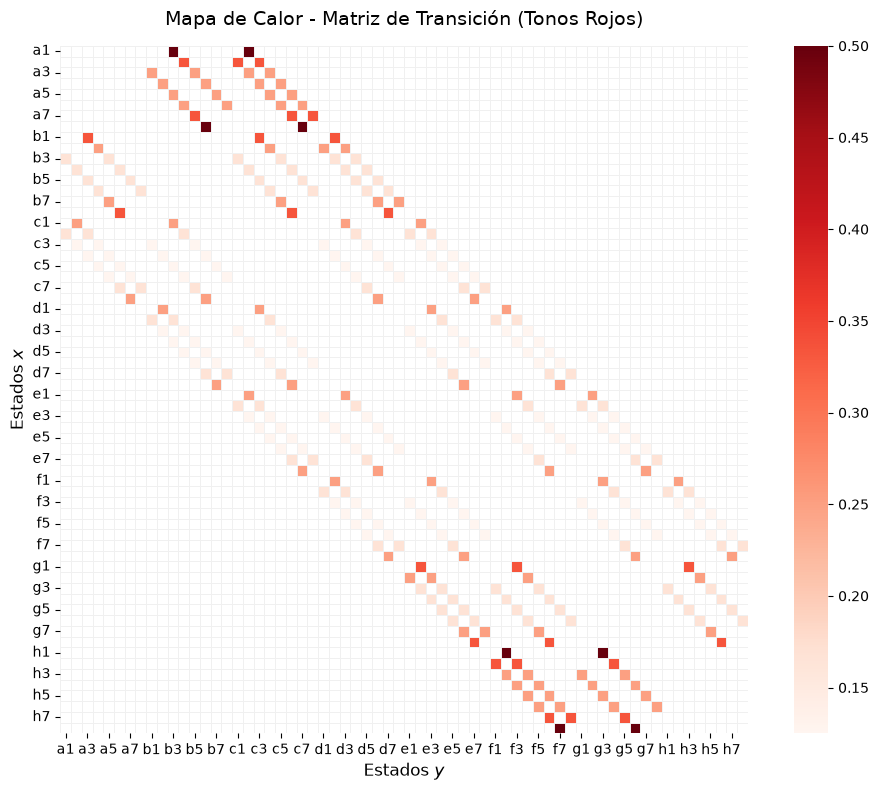

In [164]:
filas_x = [item[0] for item in resultados]
columnas_y = [y for item in resultados for y in item[1]]
todos_los_estados = sorted(list(set(filas_x + columnas_y)))

# 2. Crear el DataFrame con ceros
matriz = pd.DataFrame(0.0, index=todos_los_estados, columns=todos_los_estados)

# 3. Rellenar las probabilidades P(x, y) = 1 / |N(x)|
for x, N_x, len_N_x in resultados:
  probabilidad = 1.0 / len_N_x
  for y in N_x:
    if y in matriz.columns:
      matriz.loc[x, y] = probabilidad

# 4. Reemplazar los ceros por NaN para que aparezcan en blanco
matriz_limpia = matriz.replace(0.0, np.nan)

# 5. Configurar y graficar el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_limpia,
    annot=False,  # Sin números dentro de las celdas
    cmap="Reds",  # Paleta de tonos rojos
    cbar=True,  # Barra de color lateral
    square=True,  # Celdas cuadradas
    linewidths=0.5,  # Líneas divisorias para notar la cuadrícula
    linecolor="#f0f0f0",  # Líneas sutiles
    mask=matriz_limpia.isnull(),  # Fuerza a que los NaN (ceros) se queden blancos
)

plt.title(
    "Mapa de Calor - Matriz de Transición (Tonos Rojos)", fontsize=14, pad=15
)
plt.xlabel("Estados $y$", fontsize=12)
plt.ylabel("Estados $x$", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [100]:
def get_approx(n: int):

    points = np.random.uniform(-2, 2, size=(n, 2)) # size inidica la forma del arreglo, n filas y 2 columnas

    x = points[:, 0] # Toma todos los valores de la primera columna
    y = points[:, 1] # Toma todos los valores de la segunda columna

    result = x**2 + y**2 <= 1 # Forma un arreglo con valores booleanos cuando se cumple o no la condición

    inside = np.sum(result)

    estimated = np.mean(result)

    return inside, estimated

In [101]:
P_C1 = pi/16

data = []

for i in range(2, 7):
    n = 10**i
    inside, estimated = get_approx(n)
    error = round(abs(P_C1 - estimated), 8)
    data.append([f"10^{i}", inside, estimated, error])


In [102]:
print(tabulate(
    data,
    headers=["n", "points inside", "P_n(C1) (E)", "error abs"],
    tablefmt="github"
))

| n    |   points inside |   P_n(C1) (E) |   error abs |
|------|-----------------|---------------|-------------|
| 10^2 |              18 |      0.18     |  0.0163495  |
| 10^3 |             184 |      0.184    |  0.0123495  |
| 10^4 |            2037 |      0.2037   |  0.00735046 |
| 10^5 |           19493 |      0.19493  |  0.00141954 |
| 10^6 |          196616 |      0.196616 |  0.00026646 |


## 2.  Aproximar el número $\pi$

Utilice los resultados obtenidos en el punto anterior para construir una aproximación de $\pi$ $(3.14159265)$.

Un estimador $\widehat{\pi}_n$ de $\pi$ se obtiene de la siguiente forma:
$$
\widehat{\pi}_n:=16\widehat{P}_n(C1)
$$

¿Por qué se obtiene este estimador?

a) Calcule las  aproximaciones de $\pi$ para los valores de $n$ dados en 1-e).

b) Presente los resultados en una tabla que contenga:

$n$,  $\widehat{P}_n(C1)$,  $\widehat{\pi}$,  error absoluto.


El estimador se obtine dado que $\frac{\pi}{16}\approx \widehat{P}_n(C1)$, por lo cual podemos despejar y tener un estimador de $\pi$.

In [ ]:
data_2 = []

for row in data:
    n = row[0]
    p_n = row[2]
    pi_n = p_n*16
    error = round(abs(pi_n - pi), 8)
    data_2.append([n, p_n, pi_n, error])

In [ ]:
print(tabulate(
    data_2,
    headers=["n", "P_n(C1) (E)", "Pi_n (E)", "error"],
    tablefmt="github"
))

| n    |   P_n(C1) (E) |   Pi_n (E) |     error |
|------|---------------|------------|-----------|
| 10^2 |      0.22     |    3.52    | 0.378407  |
| 10^3 |      0.21     |    3.36    | 0.218407  |
| 10^4 |      0.1951   |    3.1216  | 0.0199927 |
| 10^5 |      0.19541  |    3.12656 | 0.0150326 |
| 10^6 |      0.197127 |    3.15403 | 0.0124394 |


## 3. Considere los conjuntos 

$C_{\sqrt{2}}=\{(x,y)\in\Omega : x^{2}+y^{2}\leq 2\}$ y $C_2=\{(x,y)\in\Omega: x^{2}+y^{2}\leq 2^{2}\}$.

Usando la información y repitiendo los numerales anteriores, para cada conjunto $C_i,\: i = \sqrt{2},\: 2$, 

a) Calcule la probabilidad $P(C_i)$.

b) Obtenga las correspondientes aproximaciones $\widehat{P}_n(C_i)$ de $P(C_i)$ paralos valores de $n$ dados en 1-e).

c) Deduzca un estimador de $\pi$ a partir de $\widehat{P}_n(C_i)$.

d) Obtenga las correspondientes aproximaciones $\widehat{\pi}_n$ y calcule los errores absolutos.

e) Construya una tabla que muestre, para cada $n$, las aproximaciones de $\pi$ obtenidas con los tres radios:
$$
n,\:  \widehat{\pi}_n(r=1),\:  \widehat{\pi}_n(r=\sqrt{2}),\:  \widehat{\pi}_n(r=2)
$$

f) Compare los resultados obtenidos para los diferentes radios. ¿Cuál de los tres radios parece proporcionar mejores aproximaciones de $\pi$? ¿Por qué puede suceder esto?

Teniendo la distribución uniforme, la probabilidad de $P(C_{\sqrt{2}}) = \frac{\pi \sqrt{2}^2}{16} =  \frac{\pi}{8}$ y la probabilidad de $P(C_2) = \frac{\pi2^2}{2^4} = \frac{\pi}{4}$

**a) Probabilidades exactas.**

Como $(X,Y)$ es uniforme en $\Omega=[-2,2]\times[-2,2]$, que tiene área $4^{2}=16$, para un radio $r\leq 2$ el conjunto $C_r=\{(x,y)\in\Omega: x^{2}+y^{2}\leq r^{2}\}$ es un círculo completo de área $\pi r^{2}$, luego

$$
P(C_r)=\frac{\pi r^{2}}{16}.
$$

En particular:

$$
P(C_{\sqrt{2}})=\frac{2\pi}{16}=\frac{\pi}{8}\approx 0.39269908,
\qquad
P(C_{2})=\frac{4\pi}{16}=\frac{\pi}{4}\approx 0.78539816.
$$

**b) Aproximaciones $\widehat{P}_n(C_r)$.**

Se generaliza la función del punto 1 para un radio $r$ cualquiera: es el mismo procedimiento (generar $n$ puntos uniformes en el cuadrado y contar cuántos cumplen la condición), sólo cambia la condición $x^{2}+y^{2}\leq r^{2}$.

In [ ]:
def get_approx_r(n: int, r: float):

    points = np.random.uniform(-2, 2, size=(n, 2)) # size indica la forma del arreglo, n filas y 2 columnas

    x = points[:, 0] # Toma todos los valores de la primera columna
    y = points[:, 1] # Toma todos los valores de la segunda columna

    result = x**2 + y**2 <= r**2 # Igual que antes, pero la condición ahora depende del radio r

    inside = np.sum(result)

    estimated = np.mean(result)

    return inside, estimated

In [ ]:
radios = [("sqrt(2)", np.sqrt(2)), ("2", 2)]

data_3 = {}

for label, r in radios:
    P_Ci = pi*r**2/16
    rows = []
    for i in range(2, 7):
        n = 10**i
        inside, estimated = get_approx_r(n, r)
        error = round(abs(P_Ci - estimated), 8)
        rows.append([f"10^{i}", inside, estimated, error])
    data_3[label] = rows

In [ ]:
for label, r in radios:
    print(f"r = {label}   P(C_r) = {pi*r**2/16:.8f}")
    print(tabulate(
        data_3[label],
        headers=["n", "points inside", "P_n(C_r) (E)", "error abs"],
        tablefmt="github"
    ))
    print()

r = sqrt(2)   P(C_r) = 0.39269908
| n    |   points inside |   P_n(C_r) (E) |   error abs |
|------|-----------------|----------------|-------------|
| 10^2 |              38 |       0.38     |  0.0126991  |
| 10^3 |             381 |       0.381    |  0.0116991  |
| 10^4 |            3900 |       0.39     |  0.00269908 |
| 10^5 |           39230 |       0.3923   |  0.00039908 |
| 10^6 |          392409 |       0.392409 |  0.00029008 |

r = 2   P(C_r) = 0.78539816
| n    |   points inside |   P_n(C_r) (E) |   error abs |
|------|-----------------|----------------|-------------|
| 10^2 |              85 |       0.85     |  0.0646018  |
| 10^3 |             771 |       0.771    |  0.0143982  |
| 10^4 |            7812 |       0.7812   |  0.00419816 |
| 10^5 |           78542 |       0.78542  |  2.184e-05  |
| 10^6 |          785792 |       0.785792 |  0.00039384 |



**c) Estimador de $\pi$.**

De $P(C_r)=\dfrac{\pi r^{2}}{16}$ se despeja $\pi=\dfrac{16\,P(C_r)}{r^{2}}$, por lo cual un estimador natural es

$$
\widehat{\pi}_n:=\frac{16}{r^{2}}\,\widehat{P}_n(C_r).
$$

Para $r=1$ esto da $16\widehat{P}_n$ (el del punto 2), para $r=\sqrt{2}$ da $8\widehat{P}_n$ y para $r=2$ da $4\widehat{P}_n$.

**d) Aproximaciones de $\pi$ y errores absolutos.**

In [ ]:
data_3_pi = {}

for label, r in radios:
    rows = []
    for row in data_3[label]:
        n = row[0]
        p_n = row[2]
        pi_n = 16*p_n/r**2
        error = round(abs(pi_n - pi), 8)
        rows.append([n, p_n, pi_n, error])
    data_3_pi[label] = rows

In [ ]:
for label, r in radios:
    print(f"r = {label}")
    print(tabulate(
        data_3_pi[label],
        headers=["n", "P_n(C_r) (E)", "Pi_n (E)", "error abs"],
        tablefmt="github"
    ))
    print()

r = sqrt(2)
| n    |   P_n(C_r) (E) |   Pi_n (E) |   error abs |
|------|----------------|------------|-------------|
| 10^2 |       0.38     |    3.04    |  0.101593   |
| 10^3 |       0.381    |    3.048   |  0.0935926  |
| 10^4 |       0.39     |    3.12    |  0.0215927  |
| 10^5 |       0.3923   |    3.1384  |  0.00319265 |
| 10^6 |       0.392409 |    3.13927 |  0.00232065 |

r = 2
| n    |   P_n(C_r) (E) |   Pi_n (E) |   error abs |
|------|----------------|------------|-------------|
| 10^2 |       0.85     |    3.4     |  0.258407   |
| 10^3 |       0.771    |    3.084   |  0.0575927  |
| 10^4 |       0.7812   |    3.1248  |  0.0167926  |
| 10^5 |       0.78542  |    3.14168 |  8.735e-05  |
| 10^6 |       0.785792 |    3.14317 |  0.00157535 |



**e) Comparación de los tres radios.**

Para $r=1$ se reutilizan las aproximaciones ya calculadas en los puntos 1 y 2 (`data_2`).

In [ ]:
data_cmp = []

for k in range(len(data_2)):
    n = data_2[k][0]
    pi_r1 = data_2[k][2]                    # viene del punto 2
    pi_r2 = data_3_pi["sqrt(2)"][k][2]
    pi_r3 = data_3_pi["2"][k][2]
    data_cmp.append([n, pi_r1, pi_r2, pi_r3])

print(tabulate(
    data_cmp,
    headers=["n", "Pi_n (r=1)", "Pi_n (r=sqrt(2))", "Pi_n (r=2)"],
    tablefmt="github"
))

| n    |   Pi_n (r=1) |   Pi_n (r=sqrt(2)) |   Pi_n (r=2) |
|------|--------------|--------------------|--------------|
| 10^2 |      3.52    |            3.04    |      3.4     |
| 10^3 |      3.36    |            3.048   |      3.084   |
| 10^4 |      3.1216  |            3.12    |      3.1248  |
| 10^5 |      3.12656 |            3.1384  |      3.14168 |
| 10^6 |      3.15403 |            3.13927 |      3.14317 |


In [ ]:
errores = []

for row in data_cmp:
    errores.append([row[0]] + [round(abs(v - pi), 8) for v in row[1:]])

print(tabulate(
    errores,
    headers=["n", "error (r=1)", "error (r=sqrt(2))", "error (r=2)"],
    tablefmt="github"
))

| n    |   error (r=1) |   error (r=sqrt(2)) |   error (r=2) |
|------|---------------|---------------------|---------------|
| 10^2 |     0.378407  |          0.101593   |    0.258407   |
| 10^3 |     0.218407  |          0.0935926  |    0.0575927  |
| 10^4 |     0.0199927 |          0.0215927  |    0.0167926  |
| 10^5 |     0.0150326 |          0.00319265 |    8.735e-05  |
| 10^6 |     0.0124394 |          0.00232065 |    0.00157535 |


**f) ¿Cuál radio aproxima mejor?**

El radio $r=2$. La razón es la varianza del estimador. Como $\widehat{P}_n(C_r)$ es una proporción binomial con $p=P(C_r)=\pi r^{2}/16$,

$$
\operatorname{Var}\big(\widehat{\pi}_n\big)
=\left(\frac{16}{r^{2}}\right)^{2}\frac{p(1-p)}{n}
=\frac{1}{n}\cdot\frac{16\pi}{r^{2}}\left(1-\frac{\pi r^{2}}{16}\right).
$$

Evaluando:

| $r$ | $p=P(C_r)$ | $n\cdot\operatorname{Var}(\widehat{\pi}_n)$ |
|---|---|---|
| $1$ | $\pi/16\approx 0.1963$ | $16\pi-\pi^{2}\approx 40.39$ |
| $\sqrt{2}$ | $\pi/8\approx 0.3927$ | $8\pi-\pi^{2}\approx 15.26$ |
| $2$ | $\pi/4\approx 0.7854$ | $4\pi-\pi^{2}\approx 2.70$ |

Es decir, la desviación estándar de $\widehat{\pi}_n$ con $r=2$ es cerca de $\sqrt{40.39/2.70}\approx 3.9$ veces menor que con $r=1$, para el mismo $n$.

La intuición: el factor de amplificación $16/r^{2}$ multiplica el error de estimación de la proporción, y ese factor es máximo cuando el círculo es pequeño. Con $r=1$ sólo cerca del 20% de los puntos cae dentro, así que la información útil por punto es baja y el error se multiplica por 16; con $r=2$ el círculo está inscrito en el cuadrado, casi el 79% de los puntos cae dentro y el error sólo se multiplica por 4. Por eso el método clásico de Monte Carlo para $\pi$ usa justamente el círculo inscrito.

(En una corrida particular puede pasar que un $r$ menor dé un error más pequeño por azar; lo que se afirma aquí es sobre el error *esperado*, y se confirma al mirar la tendencia sobre todos los $n$.)